## 7. Gaussian Mixture Model (GMM)

In [2]:
#!pip install pyod
#!pip install combo

In [1]:
######################
# Helper functions
######################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyod.utils.data import generate_data

def DGP(
    contamination=0.05,
    n_train=500,
    n_test=500,
    n_features=6,
    random_state=123,
    shift=True,
    return_df=True
):
    """
    Data Generating Process (DGP) for anomaly detection examples.

    Parameters
    ----------
    contamination : float
        Percentage of outliers
    n_train : int
        Number of training samples
    n_test : int
        Number of test samples
    n_features : int
        Number of features
    random_state : int
        Seed for reproducibility
    shift : bool
        Apply transformation (e.g., 5 - X)
    return_df : bool
        Return pandas DataFrame if True

    Returns
    -------
    X_train, X_test, y_train, y_test
    """

    X_train, X_test, y_train, y_test = generate_data(
        n_train=n_train,
        n_test=n_test,
        n_features=n_features,
        contamination=contamination,
        random_state=random_state
    )

    X_train = 5 - X_train
    X_test = 5 - X_test

    if return_df:
        X_train = pd.DataFrame(X_train)
        X_test = pd.DataFrame(X_test)

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = DGP(
    contamination=0.05,
    n_train=500,
    n_test=500,
    n_features=6,
    random_state=123,
    shift=True,
    return_df=True
)

def plot_generated_data(x1,x2,y_train):
    # Plot
    plt.scatter(x1, x2, c=y_train, alpha=0.8)
    plt.title('Scatter plot')
    plt.xlabel('x0')
    plt.ylabel('x1')
    plt.show()

def evaluate_model(model, X_train, X_test):
    """
    Generate scores, predictions, and threshold for train and test data.

    Parameters
    ----------
    model : trained model
    X_train : array-like
    X_test : array-like

    Returns
    -------
    results : dict
        Contains scores, 
        predictions, and 
        threshold
    """

    results = {
        "train_scores": model.decision_function(X_train),
        "train_pred": model.predict(X_train),
        "test_scores": model.decision_function(X_test),
        "test_pred": model.predict(X_test),
        "threshold": getattr(model, "threshold_", None)
    }

    return results

def count_stat(vector):
    # Because it is '0' and '1', we can run a count statistic.
    unique, counts = np.unique(vector, return_counts=True)
    return dict(zip(unique, counts))

def plot_hist(scores, title="Outlier Score"):
    """
    Plot histogram of outlier scores.

    Parameters
    ----------
    scores : array-like
        Outlier scores
    title : str
        Title of the plot
    """

    plt.hist(scores, bins='auto')
    plt.title(title)
    plt.show()

def descriptive_stat_threshold(X, scores, threshold, feature_names=None):
    """
    Generate descriptive statistics for normal and outlier groups.

    Parameters
    ----------
    X : array-like
        Input data
    scores : array-like
        Outlier scores
    threshold : float
        Threshold to classify outliers
    feature_names : list, optional
        Feature names for labeling columns

    Returns
    -------
    summary : DataFrame
        Count, percentage, and mean statistics by group
    """

    df = pd.DataFrame(X)

    # Assign feature names if provided
    if feature_names:
        df.columns = feature_names

    # Add score and group label
    df["Anomaly_Score"] = scores
    df["Group"] = np.where(df["Anomaly_Score"] < threshold, "Normal", "Outlier")

    # Count and percentage
    count = (
        df.groupby("Group")["Anomaly_Score"]
        .count()
        .reset_index()
        .rename(columns={"Anomaly_Score": "Count"})
    )
    count["Count %"] = count["Count"] / count["Count"].sum() * 100

    # Mean statistics
    stats = (
        df.groupby("Group")
        .mean(numeric_only=True)
        .round(2)
        .reset_index()
    )

    # Merge results
    summary = count.merge(stats, on="Group")

    return summary

def confusion_matrix(actual, scores, threshold):
    """
    Create a confusion matrix using actual labels and outlier scores.

    Parameters
    ----------
    actual : array-like
        True labels (0 = normal, 1 = outlier)
    scores : array-like
        Outlier scores
    threshold : float
        Threshold to classify outliers

    Returns
    -------
    cm : DataFrame
        Confusion matrix
    """

    df = pd.DataFrame({
        "Actual": actual,
        "Score": scores
    })

    # Convert scores to predicted labels
    df["Pred"] = np.where(df["Score"] <= threshold, 0, 1)

    # Generate confusion matrix
    cm = pd.crosstab(df["Actual"], df["Pred"])

    return cm

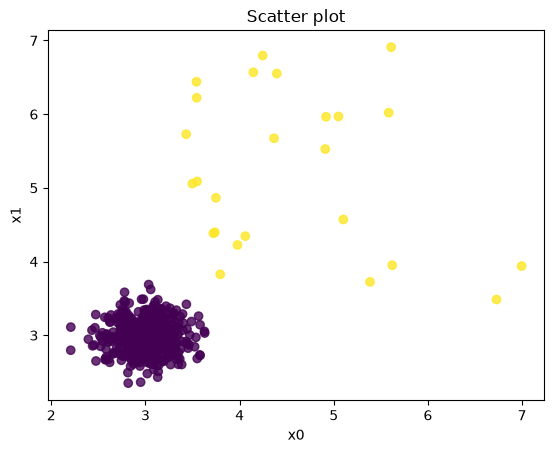

In [3]:
X_train, X_test, y_train, y_test = DGP(
    contamination=0.05,
    n_train=500,
    n_test=500,
    n_features=6,
    random_state=123,
    shift=True,
    return_df=True
)
plot_generated_data(X_train[0],X_train[1],y_train)

### Step 1: Build the model

In [4]:
from pyod.models.gmm import GMM
gmm = GMM(n_components=4, contamination=0.05)
gmm.fit(X_train)

results = evaluate_model(gmm, X_train, X_test)
y_train_scores = results["train_scores"]
y_train_pred = results["train_pred"]

y_test_scores = results["test_scores"]
y_test_pred = results["test_pred"]
threshold = results["threshold"]

In [5]:
# Threshold for the defined comtanimation rate
print("The threshold for the defined contamination rate:" , threshold)
print("The training data:", count_stat(y_train_pred))
print("The test data:", count_stat(y_test_pred))

The threshold for the defined contamination rate: 6.106452422388473
The training data: {np.int64(0): np.int64(475), np.int64(1): np.int64(25)}
The test data: {np.int64(0): np.int64(472), np.int64(1): np.int64(28)}


In [6]:
gmm.get_params()

{'contamination': 0.05,
 'covariance_type': 'full',
 'init_params': 'kmeans',
 'max_iter': 100,
 'means_init': None,
 'n_components': 4,
 'n_init': 1,
 'precisions_init': None,
 'random_state': None,
 'reg_covar': 1e-06,
 'tol': 0.001,
 'warm_start': False,
 'weights_init': None}

### Step 2: Determine the threshold

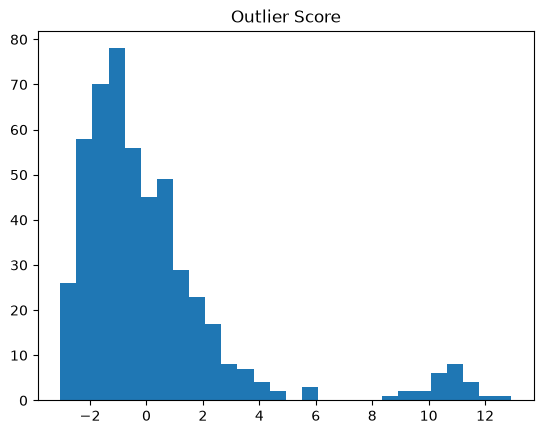

In [7]:
plot_hist(y_train_scores)

### Step 3: Descriptive statistics

In [8]:
feature_list = ['F1','F2','F3','F4','F4','F5']
descriptive_stat_threshold(X_train,y_train_scores, threshold,feature_list)

,Group,Count,Count %,F1,F2,F3,F4,F4,F5,Anomaly_Score
0,Normal,475,95.0,3.00,2.99,2.99,3.01,2.99,3.02,-0.37
1,Outlier,25,5.0,4.55,5.21,5.47,5.23,5.03,5.06,10.69


In [9]:
descriptive_stat_threshold(X_test,y_test_scores, threshold,feature_list)

,Group,Count,Count %,F1,F2,F3,F4,F4,F5,Anomaly_Score
0,Normal,472,94.4,2.99,2.99,2.99,3.01,2.99,3.00,-0.30
1,Outlier,28,5.6,4.76,5.25,4.97,4.82,4.85,4.69,14.54


In [10]:
confusion_matrix(y_test, y_test_scores, threshold)

Pred,0,1
Actual,,
0.0,472,3
1.0,0,25


### Averages

In [11]:
from pyod.models.combination import aom, moa, average, maximization
from pyod.utils.utility import standardizer
from pyod.models.gmm import GMM

# Standardize data
X_train_norm, X_test_norm = standardizer(X_train, X_test)

# Test a range of clusters from 2 to 8. There will be 7 models.
n_clf = 7
k_list = [2, 3, 4, 5, 6, 7, 8]
n_clf = len(k_list)
# Just prepare data frames so we can store the model results
train_scores = np.zeros([X_train.shape[0], n_clf])
test_scores = np.zeros([X_test.shape[0], n_clf])

# Modeling
for i in range(n_clf):
    k = k_list[i]
    gmm = GMM(n_components = k, contamination=0.05)
    gmm.fit(X_train_norm)
    # Store the results in each column:
    train_scores[:, i] = gmm.decision_function(X_train_norm)
    test_scores[:, i] = gmm.decision_function(X_test_norm)
# Decision scores have to be normalized before combination
train_scores_norm, test_scores_norm = standardizer(train_scores,test_scores)

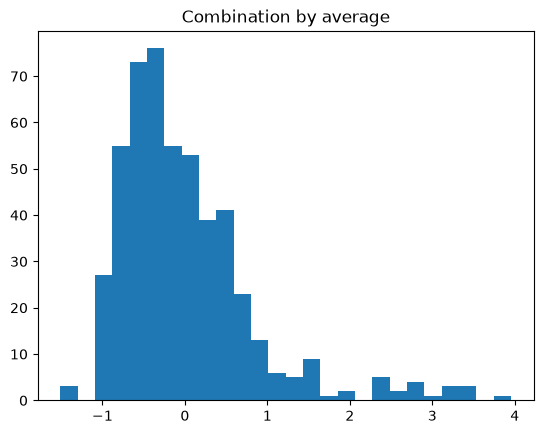

In [12]:
# Combination by average
# The test_scores_norm is 500 x 7. The "average" function will take the average of the 7 columns.
# The result "y_by_average" is a single column:
y_train_by_average = average(train_scores_norm)
y_test_by_average = average(test_scores_norm)

plot_hist(y_train_by_average, title="Combination by average")

In [13]:
descriptive_stat_threshold(X_train,y_train_by_average, 2.0,feature_list)

,Group,Count,Count %,F1,F2,F3,F4,F4,F5,Anomaly_Score
0,Normal,480,96.0,3.03,3.02,3.02,3.03,3.04,3.04,-0.12
1,Outlier,20,4.0,4.20,5.04,5.38,5.35,4.49,5.07,2.87


In [14]:
descriptive_stat_threshold(X_test,y_test_by_average, 2.0,feature_list)

,Group,Count,Count %,F1,F2,F3,F4,F4,F5,Anomaly_Score
0,Normal,470,94.0,2.98,2.99,2.99,3.02,2.99,3.00,-0.10
1,Outlier,30,6.0,4.65,5.11,4.84,4.65,4.74,4.57,15.41
